In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [79]:
cases_df = pd.read_csv("cases.tsv", sep='\t')
entitlements_df = pd.read_stata("all_entitlements.dta")

In [80]:
cases_df.head()

,case_name,CEQA,names,names_count,parking_mentions,affordability_mentions,community_mentions,num_words,num_nonstopgap_words,sentiment_pos,sentiment_neg,sentiment_neutral,date,area,txt_file_name
0,01DepartmentalRepor,NaN,[],0,1,0,0,203,122,0.256825,0.009197,0.733978,01-05-2011,West,txt/01-05-10audio_01DepartmentalReport.txt
1,02CommissionBusines,NaN,[],0,1,0,1,810,419,0.099221,0.269955,0.630824,01-05-2011,West,txt/01-05-10audio_02CommissionBusiness.txt
2,03ZA09-2885&04ZA09-2886,ENV-2009-2884-CE,"[('David', 'Carlat')]",1,9,0,3,9972,5145,0.064828,0.214557,0.720616,01-05-2011,West,txt/01-05-10audio_03ZA09-2885_04ZA09-2886b.txt
3,04ZA09-2886,NaN,[],0,0,0,1,496,278,0.059718,0.099156,0.841126,01-05-2011,West,txt/01-05-10audio_04ZA09-2886.txt
4,05APCW10-657,ENV-2009-2730-MND-REC1,"[('Melissa', 'Talber')]",1,0,0,0,917,509,0.143066,0.052420,0.804515,01-05-2011,West,txt/01-05-10audio_05APCW10-657.txt


In [81]:
entitlements_df.head()

,case_number,case_determination,case_reviewer,primary_address,APC,assessor_parcel_number,certified_neighborhood_council,community_plan_area,short_description,entitlement,...,proposed_adding,proposed_to_be_demo,has_hearing,sanfernvalleyLA,southLA,northeastLA,eastLA,centralLA,westsideLA,harborLA
0,ENV-2017-782-EAF,,ENVIRONMENTAL,23133 W SHERMAN PL,SOUTH VALLEY,2021014053,West Hills,Canoga Park - Winnetka - Woodland Hills - West...,construction of a mixed use project consisting...,"vesting zone change, height district change, b...",...,127.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CPC-2017-781-VZCJ-HD-BL-SPR,,CITY PLANNING COMMISSION,23133 W SHERMAN PL,SOUTH VALLEY,2021014053,West Hills,Canoga Park - Winnetka - Woodland Hills - West...,construction of a mixed use project consisting...,"vesting zone change, height district change, b...",...,127.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ADM-2021-6072-TOC,REVIEW COMPLETED,ADMINISTRATIVE REVIEW,7403 N TOPANGA CANYON BLVD,SOUTH VALLEY,2023004015,Canoga Park,Canoga Park - Winnetka - Woodland Hills - West...,toc tier verification,toc tier verification,...,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ADM-2022-9386-TOC,REVIEW COMPLETED,ADMINISTRATIVE REVIEW,22155 W SHERMAN WAY,SOUTH VALLEY,2023009013,Canoga Park,Canoga Park - Winnetka - Woodland Hills - West...,n apartment building. 3 stories. fully sprink...,n apartment building. 3 stories. fully sprink...,...,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ADM-2021-778-TOC,REVIEW COMPLETED,ADMINISTRATIVE REVIEW,22015 W VANOWEN,SOUTH VALLEY,2024005025,Canoga Park,Canoga Park - Winnetka - Woodland Hills - West...,toc tier verification,toc tier verfication,...,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [97]:
def clean_case_number(case_number):
    # # Remove leading digits - ie. strip "5" from "5 DIR-2015-1282".
    # case_number = re.sub(r'^\d+', '', case_number).strip()
    
    # Ensure it starts with a consonant
    case_number = re.sub(r'^\d+\s*', '', case_number)
    # if re.match(r'^[AEIOUaeiou]', case_number):
    #     case_number = re.sub(r'^[AEIOUaeiou]', '', case_number).strip()
    
    # Remove the trailing "&" term - ie. strip "&DIR12-2066" at end of "06AA12-2102&DIR12-2066" 
    case_number = re.sub(r'&.*', '', case_number).strip()
    
    return case_number

# Apply the clean_case_number function to the dataframe
cases_df['cleaned_case_number'] = cases_df['case_name'].apply(clean_case_number)


In [98]:
# cases_df
# cases_df.to_csv("ent_check.csv")

In [100]:
proposed_adding_ls, approved_ls, approved_byid_ls, days_to_completion_ls = [], [], [], []

for index, row in cases_df.iterrows():
  if row["CEQA"] != np.NaN:
    case_num = row["CEQA"]
  else:
    case_num = row["cleaned_case_number"]
  found = 0
  for index, row in entitlements_df.iterrows():
    case_num2 = row["case_number"]
    if str(case_num) in str(case_num2):
      proposed_adding_ls.append(row["proposed_adding"])
      approved_ls.append(row["approved"])
      approved_byid_ls.append(row["approved_byid"])
      days_to_completion_ls.append(row["days_to_completion"])
      found = 1
      break
  if found == 0:
    proposed_adding_ls.append(np.NaN)
    approved_ls.append(np.NaN)
    approved_byid_ls.append(np.NaN)
    days_to_completion_ls.append(np.NaN)

len(approved_ls)

2682

In [102]:
cases_df["proposed_adding"] = proposed_adding_ls
cases_df["approved"] = approved_ls
cases_df["approved_byid"] = approved_byid_ls
cases_df["days_to_completion"] = days_to_completion_ls
cases_df.to_csv("merged_cases.csv")
cases_df.head()

,case_name,CEQA,names,names_count,parking_mentions,affordability_mentions,community_mentions,num_words,num_nonstopgap_words,sentiment_pos,...,txt_file_name,case_number,parking_per_1000,community_per_1000,affordability_per_1000,cleaned_case_number,proposed_adding,approved,approved_byid,days_to_completion
0,01DepartmentalRepor,NaN,[],0,1,0,0,203,122,0.256825,...,txt/01-05-10audio_01DepartmentalReport.txt,NaN,4.926108,0.000000,0.0,DepartmentalRepor,NaN,NaN,NaN,NaN
1,02CommissionBusines,NaN,[],0,1,0,1,810,419,0.099221,...,txt/01-05-10audio_02CommissionBusiness.txt,NaN,1.234568,1.234568,0.0,CommissionBusines,NaN,NaN,NaN,NaN
2,03ZA09-2885&04ZA09-2886,ENV-2009-2884-CE,"[('David', 'Carlat')]",1,9,0,3,9972,5145,0.064828,...,txt/01-05-10audio_03ZA09-2885_04ZA09-2886b.txt,ENV-2009-2884-CE,0.902527,0.300842,0.0,ZA09-2885,NaN,NaN,NaN,NaN
3,04ZA09-2886,NaN,[],0,0,0,1,496,278,0.059718,...,txt/01-05-10audio_04ZA09-2886.txt,NaN,0.000000,2.016129,0.0,ZA09-2886,NaN,NaN,NaN,NaN
4,05APCW10-657,ENV-2009-2730-MND-REC1,"[('Melissa', 'Talber')]",1,0,0,0,917,509,0.143066,...,txt/01-05-10audio_05APCW10-657.txt,ENV-2009-2730-MND-REC1,0.000000,0.000000,0.0,APCW10-657,NaN,NaN,NaN,NaN


In [103]:
df_cleaned = cases_df.dropna(subset=['days_to_completion'])
df_cleaned

,case_name,CEQA,names,names_count,parking_mentions,affordability_mentions,community_mentions,num_words,num_nonstopgap_words,sentiment_pos,...,txt_file_name,case_number,parking_per_1000,community_per_1000,affordability_per_1000,cleaned_case_number,proposed_adding,approved,approved_byid,days_to_completion
37,6 CPC-2014-2947,ENV-2014-2948-MND,"[('Patty', 'Burman')]",1,32,17,1,9153,5110,0.354775,...,txt/01-12-17audio_6CPC-2014-2947.txt,ENV-2014-2948-MND,3.496121,0.109254,1.857315,CPC-2014-2947,163.0,1.0,1.0,525.0
38,7 CPC-2016-1735,ENV-2016-1736-CE,"[('Kenikia', 'Gardner')]",1,18,1,1,3206,1723,0.276063,...,txt/01-12-17audio_7CPC-2016-1735.txt,ENV-2016-1736-CE,5.614473,0.311915,0.311915,CPC-2016-1735,48.0,1.0,1.0,614.0
91,4 TT-73626,ENV-2016-1747-CE,"[('Courtney', 'Schum')]",1,1,1,1,8112,4244,0.095521,...,txt/01-24-2017audio_4TT-73626.txt,ENV-2016-1747-CE,0.123274,0.123274,0.123274,TT-73626,15.0,1.0,1.0,126.0
104,9 CPC-2016-2881,ENV-2016-2882-MND,"[('Peter', 'Jeans')]",1,5,2,4,2584,1434,0.306944,...,txt/01-26-17audio_9CPC-2016-2881.txt,ENV-2016-2882-MND,1.934985,1.547988,0.773994,CPC-2016-2881,170.0,1.0,1.0,113.0
141,6 VTT-72928,ENV-2014-4617-MND,"[('Robert', 'Sliduk'), ('Brad', 'Wise'), ('Ang...",4,33,7,3,6655,3557,0.176015,...,txt/02-09-17audio_6VTT-72928.txt,ENV-2014-4617-MND,4.958678,0.450789,1.051841,VTT-72928,85.0,1.0,1.0,416.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2258,6 APCSV-2016-120-ZC-SPPA-SP,ENV-2016-121-MND,"[('Peg', 'Malone'), ('Adam', 'Goldberg'), ('Pe...",4,6,2,8,10804,5696,0.222925,...,txt/SV102617audio_6APCSV-2016-120-ZC-SPPA-SPP.txt,ENV-2016-121-MND,0.555350,0.740466,0.185117,APCSV-2016-120-ZC-SPPA-SP,12.0,1.0,1.0,404.0
2422,7 ZA-2015-1473-CDP-1,ENV-2013-3872-ND,[],0,0,0,0,1076,562,0.074255,...,txt/WLA02-17-16audio_7ZA-2015-1473-CDP-1A.txt,ENV-2013-3872-ND,0.000000,0.000000,0.000000,ZA-2015-1473-CDP-1,2.0,1.0,1.0,578.0
2431,10 ZA-2014-3007-CD,ENV-2014-3008-MND,"[('Jonathan', 'Hershey')]",1,0,0,0,198,134,0.119943,...,txt/WLA03-16-16audio_10ZA-2014-3007-CDP.txt,ENV-2014-3008-MND,0.000000,0.000000,0.000000,ZA-2014-3007-CD,2.0,1.0,1.0,143.0
2437,7 & 8 ZA-2015-1473 & DIR-2016-524,ENV-2013-3872-ND,"[('Jose', 'Carlos'), ('Kevin', 'Jones'), ('Geo...",6,4,6,2,20900,10546,0.098346,...,txt/WLA03-16-16audio_7_8ZA-2015-1473_DIR-2016-...,ENV-2013-3872-ND,0.191388,0.095694,0.287081,,2.0,1.0,1.0,578.0


In [105]:
df_cleaned['proposed_adding_binary'] = df_cleaned['proposed_adding'].apply(lambda x: 1 if x >= 1 else 0)
df_cleaned

/var/folders/vq/qfqzj01x6ms_n2n90qm33bvr0000gn/T/ipykernel_65757/1468201042.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['proposed_adding_binary'] = df_cleaned['proposed_adding'].apply(lambda x: 1 if x >= 1 else 0)


,case_name,CEQA,names,names_count,parking_mentions,affordability_mentions,community_mentions,num_words,num_nonstopgap_words,sentiment_pos,...,case_number,parking_per_1000,community_per_1000,affordability_per_1000,cleaned_case_number,proposed_adding,approved,approved_byid,days_to_completion,proposed_adding_binary
37,6 CPC-2014-2947,ENV-2014-2948-MND,"[('Patty', 'Burman')]",1,32,17,1,9153,5110,0.354775,...,ENV-2014-2948-MND,3.496121,0.109254,1.857315,CPC-2014-2947,163.0,1.0,1.0,525.0,1
38,7 CPC-2016-1735,ENV-2016-1736-CE,"[('Kenikia', 'Gardner')]",1,18,1,1,3206,1723,0.276063,...,ENV-2016-1736-CE,5.614473,0.311915,0.311915,CPC-2016-1735,48.0,1.0,1.0,614.0,1
91,4 TT-73626,ENV-2016-1747-CE,"[('Courtney', 'Schum')]",1,1,1,1,8112,4244,0.095521,...,ENV-2016-1747-CE,0.123274,0.123274,0.123274,TT-73626,15.0,1.0,1.0,126.0,1
104,9 CPC-2016-2881,ENV-2016-2882-MND,"[('Peter', 'Jeans')]",1,5,2,4,2584,1434,0.306944,...,ENV-2016-2882-MND,1.934985,1.547988,0.773994,CPC-2016-2881,170.0,1.0,1.0,113.0,1
141,6 VTT-72928,ENV-2014-4617-MND,"[('Robert', 'Sliduk'), ('Brad', 'Wise'), ('Ang...",4,33,7,3,6655,3557,0.176015,...,ENV-2014-4617-MND,4.958678,0.450789,1.051841,VTT-72928,85.0,1.0,1.0,416.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2258,6 APCSV-2016-120-ZC-SPPA-SP,ENV-2016-121-MND,"[('Peg', 'Malone'), ('Adam', 'Goldberg'), ('Pe...",4,6,2,8,10804,5696,0.222925,...,ENV-2016-121-MND,0.555350,0.740466,0.185117,APCSV-2016-120-ZC-SPPA-SP,12.0,1.0,1.0,404.0,1
2422,7 ZA-2015-1473-CDP-1,ENV-2013-3872-ND,[],0,0,0,0,1076,562,0.074255,...,ENV-2013-3872-ND,0.000000,0.000000,0.000000,ZA-2015-1473-CDP-1,2.0,1.0,1.0,578.0,1
2431,10 ZA-2014-3007-CD,ENV-2014-3008-MND,"[('Jonathan', 'Hershey')]",1,0,0,0,198,134,0.119943,...,ENV-2014-3008-MND,0.000000,0.000000,0.000000,ZA-2014-3007-CD,2.0,1.0,1.0,143.0,1
2437,7 & 8 ZA-2015-1473 & DIR-2016-524,ENV-2013-3872-ND,"[('Jose', 'Carlos'), ('Kevin', 'Jones'), ('Geo...",6,4,6,2,20900,10546,0.098346,...,ENV-2013-3872-ND,0.191388,0.095694,0.287081,,2.0,1.0,1.0,578.0,1


In [106]:
summary_stats = df_cleaned.groupby('proposed_adding_binary')['sentiment_pos'].agg(['mean', 'median', 'std', 'min', 'max'])
summary_stats

,mean,median,std,min,max
proposed_adding_binary,,,,,
0,0.226801,0.226801,NaN,0.226801,0.226801
1,0.229590,0.222925,0.099884,0.043113,0.498578


In [104]:
# df_cleaned.to_csv("a.csv")

In [84]:
# cases_df["case_number"] = cases_df["CEQA"]
# merged_df = pd.merge(cases_df, entitlements_df, on='case_number', how='inner') #Merges (inner) dataframes
# merged_df.head()

,case_name,CEQA,names,names_count,parking_mentions,affordability_mentions,community_mentions,num_words,num_nonstopgap_words,sentiment_pos,...,proposed_to_be_demo,has_hearing,sanfernvalleyLA,southLA,northeastLA,eastLA,centralLA,westsideLA,harborLA,cleaned_case_number
0,6 CPC-2014-2947,ENV-2014-2948-MND,"[('Patty', 'Burman')]",1,32,17,1,9153,5110,0.354775,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,ENV-2014-2948-MND
1,7 CPC-2016-1735,ENV-2016-1736-CE,"[('Kenikia', 'Gardner')]",1,18,1,1,3206,1723,0.276063,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,ENV-2016-1736-CE
2,4 TT-73626,ENV-2016-1747-CE,"[('Courtney', 'Schum')]",1,1,1,1,8112,4244,0.095521,...,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,ENV-2016-1747-CE
3,9 CPC-2016-2881,ENV-2016-2882-MND,"[('Peter', 'Jeans')]",1,5,2,4,2584,1434,0.306944,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,ENV-2016-2882-MND
4,6 VTT-72928,ENV-2014-4617-MND,"[('Robert', 'Sliduk'), ('Brad', 'Wise'), ('Ang...",4,33,7,3,6655,3557,0.176015,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,ENV-2014-4617-MND


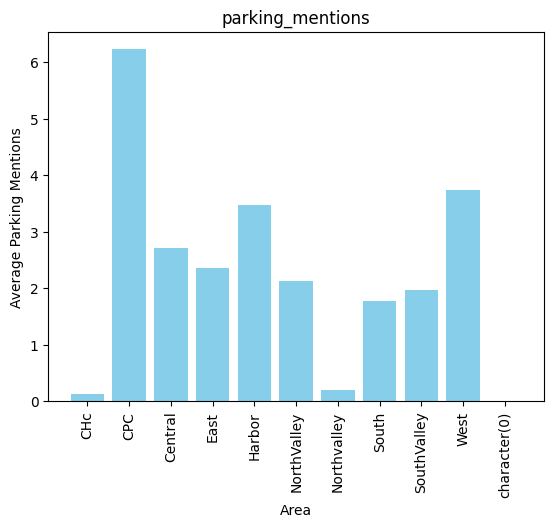

In [85]:
avr_parking_area = cases_df.groupby('area')['parking_mentions'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_parking_area['area'], avr_parking_area['parking_mentions'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Parking Mentions')
plt.title('parking_mentions')
plt.xticks(rotation=90)
plt.show()

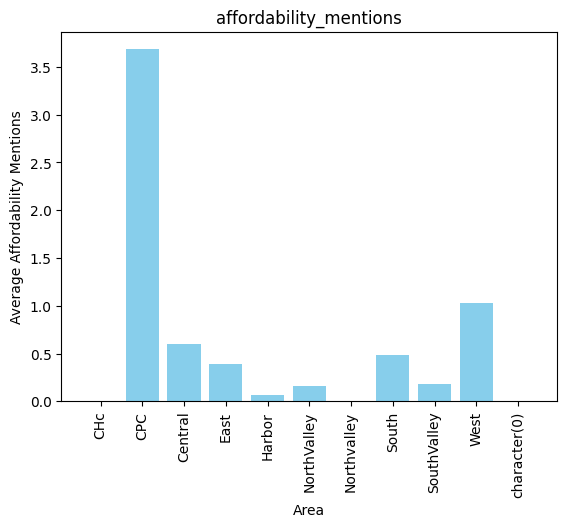

In [86]:
avr_aff_area = cases_df.groupby('area')['affordability_mentions'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_aff_area['area'], avr_aff_area['affordability_mentions'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Affordability Mentions')
plt.title('affordability_mentions')
plt.xticks(rotation=90)
plt.show()

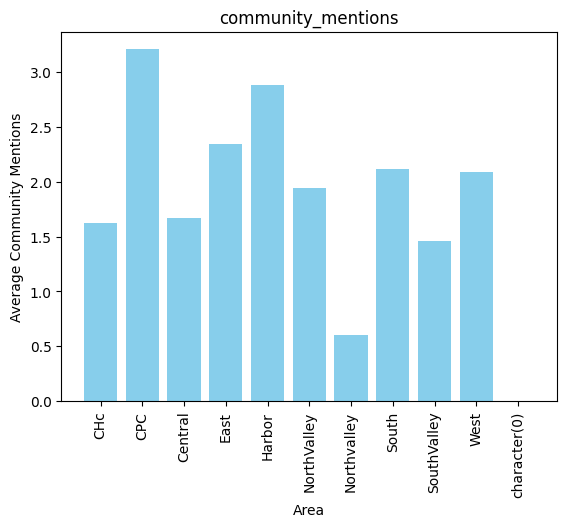

In [87]:
avr_comm_area = cases_df.groupby('area')['community_mentions'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_comm_area['area'], avr_comm_area['community_mentions'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Community Mentions')
plt.title('community_mentions')
plt.xticks(rotation=90)
plt.show()

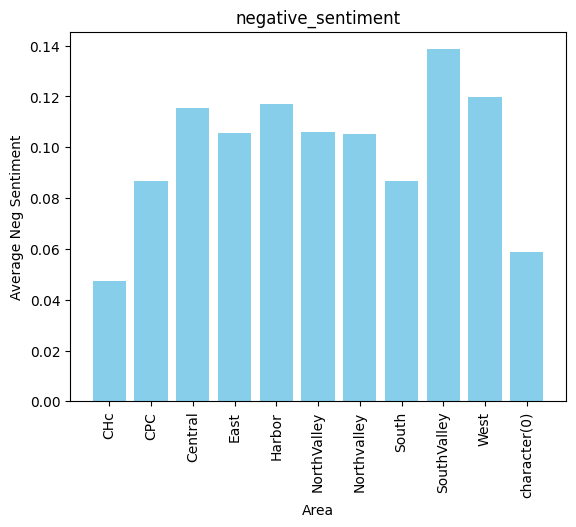

In [88]:
negative_sentiment = cases_df.groupby('area')['sentiment_neg'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(negative_sentiment['area'], negative_sentiment['sentiment_neg'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Neg Sentiment')
plt.title('negative_sentiment')
plt.xticks(rotation=90)
plt.show()

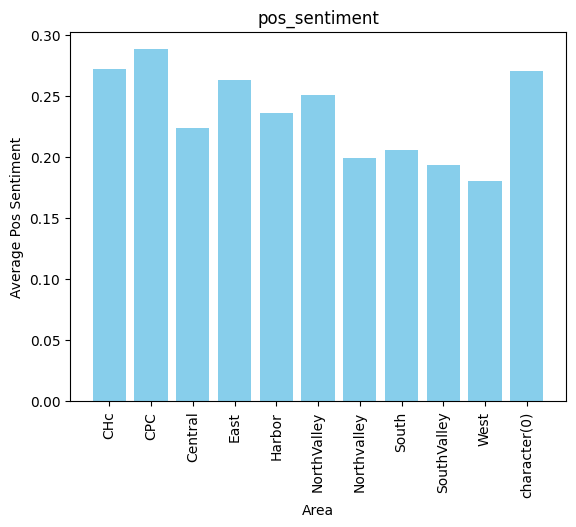

In [89]:
pos_sentiment = cases_df.groupby('area')['sentiment_pos'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(pos_sentiment['area'], pos_sentiment['sentiment_pos'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Pos Sentiment')
plt.title('pos_sentiment')
plt.xticks(rotation=90)
plt.show()

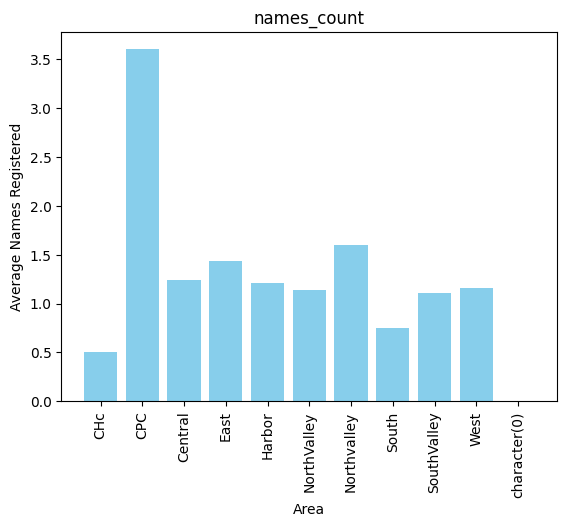

In [90]:
names_count = cases_df.groupby('area')['names_count'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(names_count['area'], names_count['names_count'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Names Registered')
plt.title('names_count')
plt.xticks(rotation=90)
plt.show()

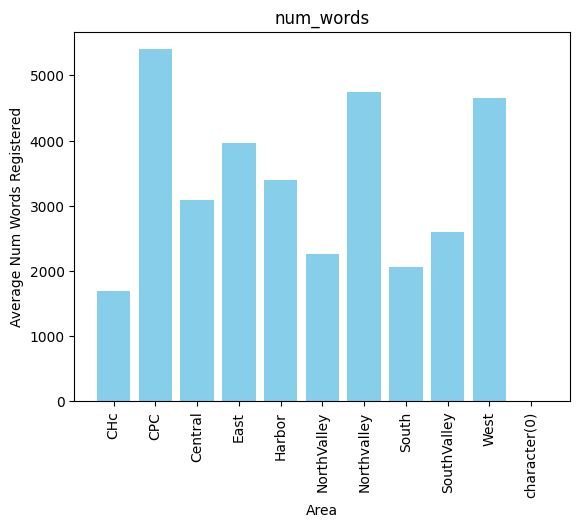

In [91]:
num_words = cases_df.groupby('area')['num_words'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(num_words['area'], num_words['num_words'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Num Words Registered')
plt.title('num_words')
plt.xticks(rotation=90)
plt.show()

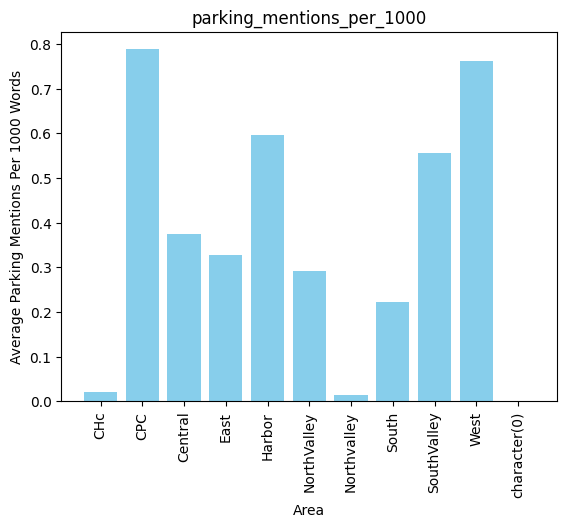

In [92]:
cases_df["parking_per_1000"] = cases_df.apply(lambda row: row['parking_mentions'] / row['num_words'] * 1000 if row['num_words'] > 0 else 0, axis=1)
avr_parking_area = cases_df.groupby('area')['parking_per_1000'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_parking_area['area'], avr_parking_area['parking_per_1000'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Parking Mentions Per 1000 Words')
plt.title('parking_mentions_per_1000')
plt.xticks(rotation=90)
plt.show()

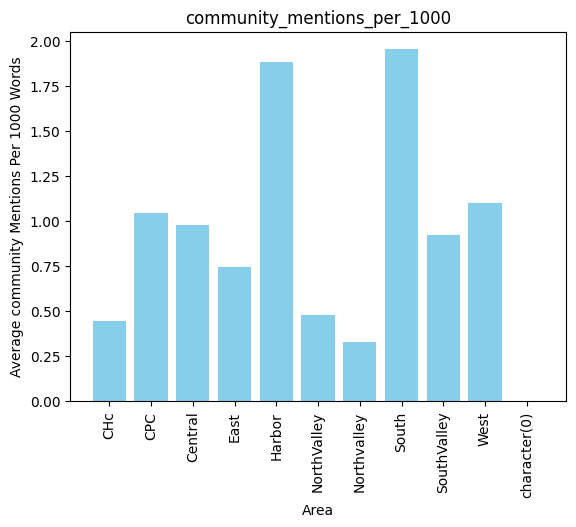

In [93]:
cases_df["community_per_1000"] = cases_df.apply(lambda row: row['community_mentions'] / row['num_words'] * 1000 if row['num_words'] > 0 else 0, axis=1)
avr_community_area = cases_df.groupby('area')['community_per_1000'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_community_area['area'], avr_community_area['community_per_1000'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average community Mentions Per 1000 Words')
plt.title('community_mentions_per_1000')
plt.xticks(rotation=90)
plt.show()

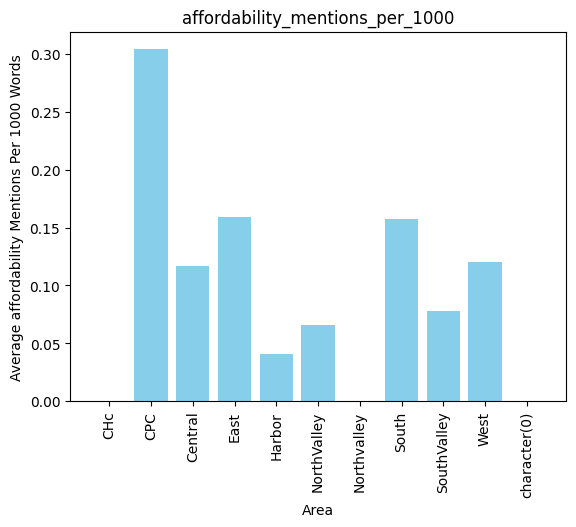

In [94]:
cases_df["affordability_per_1000"] = cases_df.apply(lambda row: row['affordability_mentions'] / row['num_words'] * 1000 if row['num_words'] > 0 else 0, axis=1)
avr_affordability_area = cases_df.groupby('area')['affordability_per_1000'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_affordability_area['area'], avr_affordability_area['affordability_per_1000'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average affordability Mentions Per 1000 Words')
plt.title('affordability_mentions_per_1000')
plt.xticks(rotation=90)
plt.show()